# pytorch workflow

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

## 1. data (preper and load)
1. get daete into a numberical representation
2. build model to learn from the data

In [2]:
# regression foumulas 
import torch
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(1)
y = weight*X + bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
X.shape,y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

### create the training and test set (sometimes validation set)

In [4]:
train_split = int(0.8*len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]
len(X_train),len(X_test),len(y_train),len(y_test)

(40, 10, 40, 10)

In [5]:
def plot_predictions(train_data=X_train,
                     train_label=y_train,
                     test_data=X_test,
                     test_label=y_test,
                     predictions=None ):
    plt.figure(figsize=(10,7))
    # plot training data in blue
    plt.scatter(train_data,train_label,label="Training" ,c="b",s=4)
    # plot test data in green
    plt.scatter(test_data,test_label,label="Test data",c="g",s=4)
    # plot predictions in red
    if predictions is not None:
        plt.scatter(test_data,predictions,label="Predictions",c="r",s=4)
    # show the legend
    plt.legend(prop={"size":14})  

    

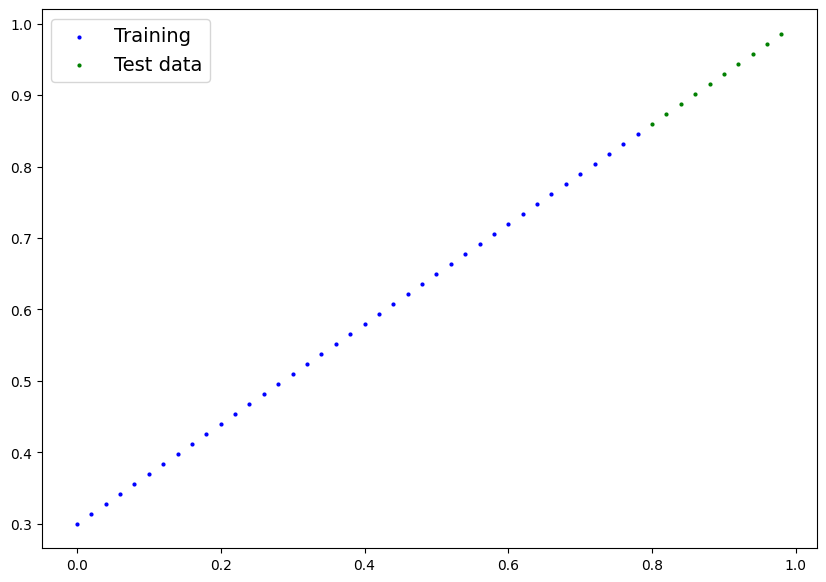

In [6]:
plot_predictions()

In [16]:
from torch import nn
import torch
class LinearRegression(nn.Module):# subclassing nn.Module
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1,
                                               requires_grad=True,
                                               dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
    def forward(self,x: torch.Tensor) -> torch.Tensor: # all nn.module subclasses requre you to overwirite forward method
        return x*self.weight + self.bias  

In [17]:
## set the random seed
torch.manual_seed(42)
## create a instance of the model
model = LinearRegression()
list(model.parameters())
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
### making prediction using `torch.ingference_mode()`
X_test
with torch.inference_mode():#  turn off the gradient calculation, speed up the prediction .that's why it called inference mode 
    y_pred = model(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

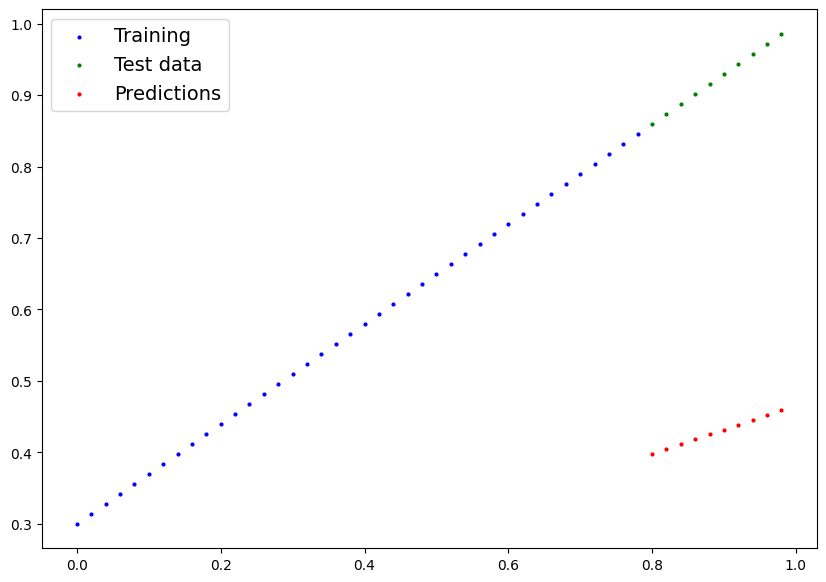

In [19]:
plot_predictions(predictions=y_pred)

## training 
- move the parameters of the model to the ideal model 
- **loss function(aka cost function)** to measure the error ,how poor you model are
    - absolute error aka. L1 loss, mean absolute error
    - MSE loss (mean square error)
- **ooptimizer** : take into accont of the loss function and adjust the model's parameters
    - SGD (stochastic gradient descent)
    - Adam optimizer


In [20]:
#check out the model parameters 
model.state_dict()
with torch.inference_mode():
    print((model.state_dict()))

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])


In [21]:
# Setup a loss function 
loss_fu = nn.L1Loss()
# Setup an optimizer 
optimizer = torch.optim.Adam(model.parameters(),lr=0.0001)

### training loop
0. loop through thar data
1. forword pass ,aka forward propagation 
2. calculate the loss (compare forward pass prediction to ground truth labels)
3. Optimizer zero grad
4. loss backward - move backward through the networdk to calculate the gradients of ezch of  the parameters 
5. optimizer step

tensor([[0.5782],
        [0.5869],
        [0.5956],
        [0.6044],
        [0.6131],
        [0.6218],
        [0.6306],
        [0.6393],
        [0.6480],
        [0.6568]])

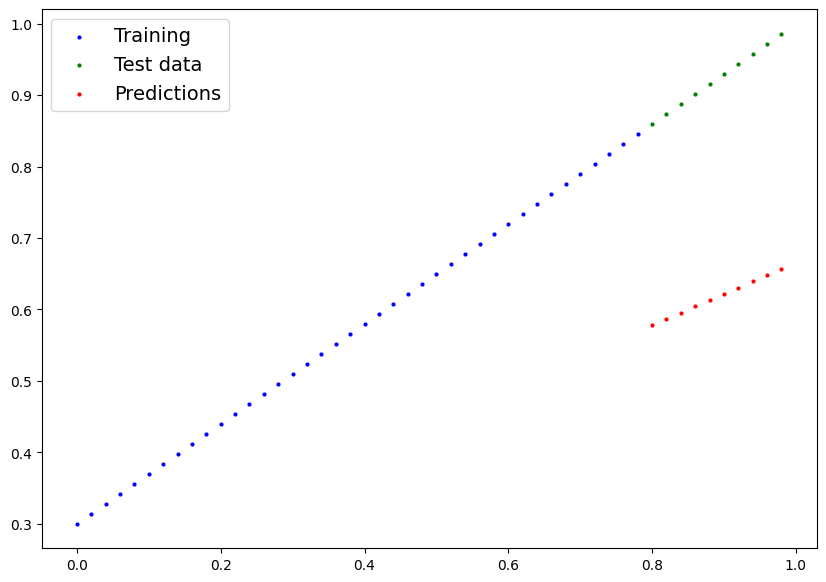

In [22]:
# an epoch is one loop through the data
# 0. loop through the data
epochs = 1000
for epoch in range(epochs):
    # set the model to training mode 
    model.train()# train mode set the parameters to gradient equal True
    # 1. forward pass 
    y_pred = model(X_train)

    # 2. calculate the Loss
    loss = loss_fu(y_pred,y_train) # input first target second

    # 3. Optimizer zero_grad
    optimizer.zero_grad()  

    # 4. perform backpropagation , backward pas 
    loss.backward()    # Use the Tensor method backword to compute the gradients after layers and loss at the end of the network
    # the backward method can be ues at the end of a series of operations to compute the gradients of the passed perameters

    # 5.step the optimizerr 
    optimizer.step()

model.eval()    # turn off something you don't want to use during the evaluation,like dropout 
with torch.inference_mode(): # turn off the gradient tracking & a couple more things 
    y_pred = model(X_test)

plot_predictions(predictions=y_pred)
y_pred

In [23]:
model.state_dict()

OrderedDict([('weight', tensor([0.4367])), ('bias', tensor([0.2288]))])

## saving and loading the model 
1. `torch.save()` - allow you to save pytorch object in pickle format 
2. `torch.load()` - load the model 
3. `torch.nn.Module.load_state_dict()` - load the state dict into the model

In [24]:
torch.save(model.state_dict(),"model.pth")
model_2 = LinearRegression()
model_2.load_state_dict(torch.load("model.pth"))
model_2.eval()
model_2.state_dict()

OrderedDict([('weight', tensor([0.4367])), ('bias', tensor([0.2288]))])

In [28]:
# use nn.layer to create a nueral network
class LinearRegression2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1,out_features=1)
    def forward(self,x):
        return self.linear_layer(x)
torch.manual_seed(42)
model_1 = LinearRegression2()
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [31]:
# change the model device 
print(next(model_1.parameters()).device)
model_1.to(device)
print(next(model_1.parameters()).device)
# put data in the same device 
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


cpu
cuda:0


In [32]:
nn.Sequential(
    nn.linear
)

SyntaxError: invalid character '（' (U+FF08) (543645419.py, line 1)

: 